# Confidence–Entropy Depth Analysis

Research-grade analysis for the confidence–entropy experiment: do LLM personas' stated confidence track their answer entropy, or does persona style dominate?

**Sections:** Setup → Load Data → Feature Engineering → Sanity Checks → Calibration → Persona Analysis → Confidence Mismatch → Correct vs Incorrect → Key Findings

## 1. Setup

Set the path to your results file (JSONL). Run this cell, then update `RESULTS_PATH` and run the rest.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Publication-ready style
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
sns.set_style("whitegrid")


# ── Set your results file path here ─────────────────────────────────────
RESULTS_PATH = "results/raw/confidence_entropy_20260302_232323.jsonl"  # .jsonl or .json

# Resolve relative to cwd or project root (parent of cwd when notebook is in analysis/)
_p = Path(RESULTS_PATH)
if not _p.is_absolute():
    for base in [Path.cwd(), Path.cwd().parent]:
        candidate = base / RESULTS_PATH
        if candidate.exists():
            RESULTS_PATH = str(candidate)
            break
    else:
        RESULTS_PATH = str(_p)
if not Path(RESULTS_PATH).exists():
    raise FileNotFoundError(f"Results file not found: {RESULTS_PATH}")


# Confidence bin midpoints (S–Z) from experiment schema
STATED_CONFIDENCE_MIDPOINTS = {
    "S": 0.025, "T": 0.075, "U": 0.15, "V": 0.3,
    "W": 0.5, "X": 0.7, "Y": 0.85, "Z": 0.95,
}
CONFIDENCE_LETTERS = list(STATED_CONFIDENCE_MIDPOINTS.keys())

## 2. Load Data

Load JSONL (or JSON array) safely; normalize columns; drop error rows. Robust to missing columns from older runs.

In [2]:
def load_ce_results(path: str | Path) -> pd.DataFrame:
    """Load confidence-entropy results from JSONL or JSON array. Robust to missing fields."""
    path = Path(path)
    records = []
    with open(path) as f:
        raw = f.read().strip()
    if not raw:
        return pd.DataFrame()
    # Single JSON array (e.g. .json export)
    if raw.strip().startswith("["):
        data = json.loads(raw)
        records = data if isinstance(data, list) else [data]
    else:
        # JSONL: one JSON object per line
        for line in raw.split("\n"):
            line = line.strip()
            if line:
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    continue
    df = pd.DataFrame(records)
    if df.empty:
        return df
    if "error" in df.columns:
        df = df[df["error"].isna()].copy()
    return df

df_raw = load_ce_results(RESULTS_PATH)
print(f"Loaded {len(df_raw)} rows (after dropping error rows).")
df_raw.head(2)

Loaded 1050 rows (after dropping error rows).


,experiment,model,persona_name,question_id,domain,source_dataset,correct_answer,open_ended_response,forced_choice_answer,forced_answer_validity,...,stated_confidence_letter,stated_confidence_midpoint,stated_confidence_raw,confidence_answer_validity,confidence_option_probs,confidence_option_logits,system_prompt,temperature,error,timestamp
0,confidence_entropy,meta-llama/Llama-3.1-8B-Instruct,default_assistant,chem_000,chemistry,mmlu_high_school_chemistry,D,The correct answer is D) H2Se > H2S > H2O.\n\n...,D,True,...,X,0.7,X,True,"{'S': 0.0006411179783754051, 'T': 0.0085780639...","{'S': 20.328125, 'T': 22.921875, 'U': 24.07812...","You are a helpful, harmless, and honest AI ass...",0.0,None,2026-03-02T23:23:50.371869+00:00
1,confidence_entropy,meta-llama/Llama-3.1-8B-Instruct,default_assistant,chem_001,chemistry,mmlu_high_school_chemistry,C,"To solve this problem, we need to use the conc...",C,True,...,X,0.7,X,True,"{'S': 0.0013201367110013962, 'T': 0.0103836786...","{'S': 21.640625, 'T': 23.703125, 'U': 25.04687...","You are a helpful, harmless, and honest AI ass...",0.0,None,2026-03-02T23:23:57.976341+00:00


## 3. Feature Engineering

Add derived columns: answer entropy (if missing), confidence entropy, expected confidence, top probs, argmax. Detect answer options (A–E) and confidence bins (S–Z) from data.

In [3]:
def safe_entropy(probs: pd.Series) -> pd.Series:
    """Entropy -sum(p*log(p)) for each row of option probs. Handles dicts and missing."""
    def one_entropy(d):
        if not isinstance(d, dict) or not d:
            return np.nan
        p = np.array(list(d.values()), dtype=float)
        p = p[p > 0]
        return -np.sum(p * np.log(p))
    return probs.map(one_entropy)

def expected_confidence_from_probs(probs: pd.Series, midpoints: dict) -> pd.Series:
    """Expected confidence = sum(prob_i * midpoint_i) over confidence bins."""
    def one_exp(d):
        if not isinstance(d, dict) or not d:
            return np.nan
        return sum(d.get(k, 0) * v for k, v in midpoints.items())
    return probs.map(one_exp)

def top_prob(probs: pd.Series) -> pd.Series:
    """Max probability over options."""
    def one_max(d):
        if not isinstance(d, dict) or not d:
            return np.nan
        return max(d.values())
    return probs.map(one_max)

def argmax_letter(probs: pd.Series) -> pd.Series:
    """Letter with highest probability."""
    def one_argmax(d):
        if not isinstance(d, dict) or not d:
            return None
        return max(d, key=d.get)
    return probs.map(one_argmax)

df = df_raw.copy()

# Answer entropy (use existing column if present)
if "answer_option_entropy" not in df.columns or df["answer_option_entropy"].isna().all():
    df["answer_entropy"] = safe_entropy(df["option_probs"]) if "option_probs" in df.columns else np.nan
else:
    df["answer_entropy"] = df["answer_option_entropy"]

# Confidence entropy from S–Z probs
if "confidence_option_probs" in df.columns:
    df["confidence_entropy"] = safe_entropy(df["confidence_option_probs"])
else:
    df["confidence_entropy"] = np.nan

# Expected confidence (from S–Z probs)
if "confidence_option_probs" in df.columns:
    df["expected_confidence"] = expected_confidence_from_probs(df["confidence_option_probs"], STATED_CONFIDENCE_MIDPOINTS)
else:
    df["expected_confidence"] = df.get("stated_confidence_midpoint", np.nan)

# Stated confidence midpoint (parsed letter -> midpoint)
if "stated_confidence_midpoint" not in df.columns and "stated_confidence_letter" in df.columns:
    df["stated_confidence_midpoint"] = df["stated_confidence_letter"].map(STATED_CONFIDENCE_MIDPOINTS)

# Use stated as fallback for expected when we don't have confidence probs
if df["expected_confidence"].isna().all() and "stated_confidence_midpoint" in df.columns:
    df["expected_confidence"] = df["stated_confidence_midpoint"]

# Answer top prob
df["answer_top_prob"] = top_prob(df["option_probs"]) if "option_probs" in df.columns else np.nan

# Confidence top prob and argmax
if "confidence_option_probs" in df.columns:
    df["confidence_top_prob"] = top_prob(df["confidence_option_probs"])
    df["confidence_argmax"] = argmax_letter(df["confidence_option_probs"])
else:
    df["confidence_top_prob"] = np.nan
    df["confidence_argmax"] = df.get("stated_confidence_letter", None)

print("Derived columns added. Sample:")
cols_show = [c for c in ["answer_entropy", "confidence_entropy", "expected_confidence", "answer_top_prob", "stated_confidence_midpoint"] if c in df.columns]
df[cols_show].head()

Derived columns added. Sample:


,answer_entropy,confidence_entropy,expected_confidence,answer_top_prob,stated_confidence_midpoint
0,0.949339,1.685224,0.661259,0.635739,0.70
1,1.286671,1.650703,0.647507,0.361833,0.70
2,1.022258,1.780068,0.646423,0.650996,0.70
3,0.961437,1.689129,0.648906,0.643550,0.70
4,1.072585,1.666950,0.704198,0.507336,0.95


## 4. Sanity Checks

Trials per persona, accuracy, mean entropy, mean stated confidence, invalid-output rate. Histograms of answer entropy and expected confidence.

In [4]:
persona_col = "persona_name" if "persona_name" in df.columns else "persona"
personas = df[persona_col].dropna().unique()

summary = []
for p in sorted(personas):
    sub = df[df[persona_col] == p]
    n = len(sub)
    acc = sub["is_correct"].mean() if "is_correct" in sub.columns and sub["is_correct"].notna().any() else np.nan
    mean_ent = sub["answer_entropy"].mean() if "answer_entropy" in sub.columns else np.nan
    mean_conf = sub["stated_confidence_midpoint"].mean() if "stated_confidence_midpoint" in sub.columns else np.nan
    mean_exp_conf = sub["expected_confidence"].mean() if "expected_confidence" in sub.columns else np.nan
    invalid = 0
    if "forced_answer_validity" in sub.columns:
        invalid = (~sub["forced_answer_validity"]).sum()
    if "confidence_answer_validity" in sub.columns:
        invalid += (~sub["confidence_answer_validity"]).sum()
    summary.append({"persona": p, "n": n, "accuracy": acc, "mean_answer_entropy": mean_ent, "mean_stated_conf": mean_conf, "mean_expected_conf": mean_exp_conf, "n_invalid": invalid})

summary_df = pd.DataFrame(summary)
summary_df["frac_invalid"] = (summary_df["n_invalid"] / summary_df["n"]).round(4)
print("Summary per persona:")
display(summary_df)

Summary per persona:


,persona,n,accuracy,mean_answer_entropy,mean_stated_conf,mean_expected_conf,n_invalid,frac_invalid
0,artist,150,0.766667,0.396333,0.547819,0.518146,10,0.0667
1,bold_assertive,150,0.753333,0.387072,0.942167,0.898416,0,0.0000
2,cautious_hedging,150,0.706667,0.433788,0.174500,0.216522,0,0.0000
3,chemist,150,0.753333,0.385230,0.502000,0.495710,0,0.0000
4,default_assistant,150,0.746667,0.349210,0.602500,0.613597,0,0.0000
5,five_year_old,150,0.660000,0.468529,0.214000,0.359694,0,0.0000
6,historian,150,0.753333,0.379354,0.688167,0.635081,5,0.0333


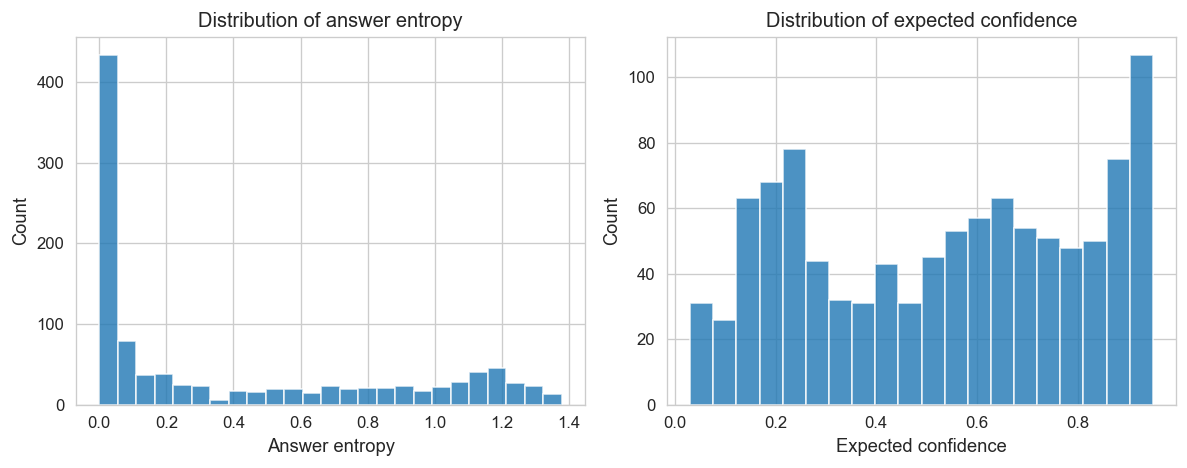

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["answer_entropy"].dropna().hist(ax=axes[0], bins=25, edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Answer entropy")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of answer entropy")
df["expected_confidence"].dropna().hist(ax=axes[1], bins=20, edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Expected confidence")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of expected confidence")
plt.tight_layout()
plt.show()

## 5. Calibration Analysis

**A)** Expected confidence vs empirical accuracy (reliability curve).  
**B)** Answer entropy vs expected confidence (scatter + regression, colored by persona).  
**C)** Margin vs confidence (scatter with smoothing).

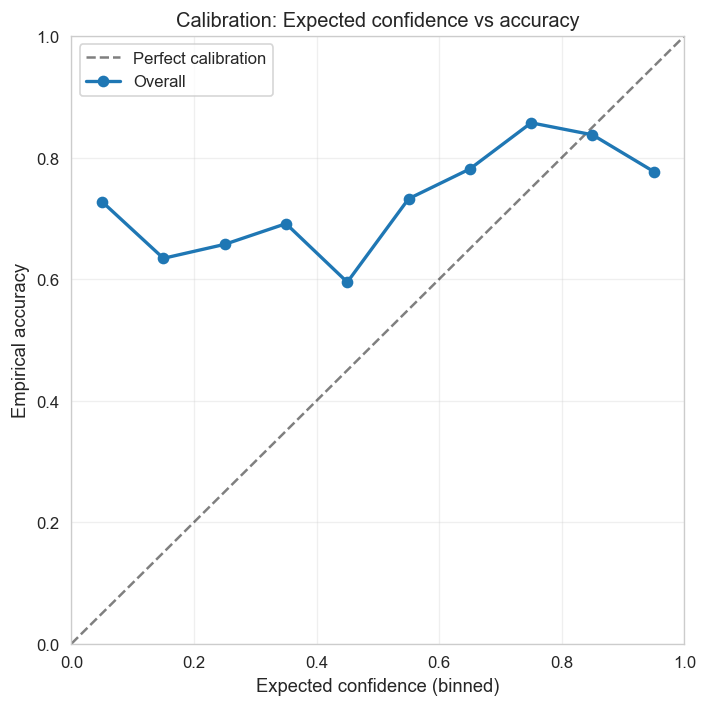

In [6]:
# A) Reliability curve: bin by expected confidence, plot actual accuracy per bin
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")

bins = np.linspace(0, 1, 11)
valid = df["expected_confidence"].notna() & df["is_correct"].notna()
sub = df.loc[valid]
if len(sub) >= 10:
    bin_idx = np.digitize(sub["expected_confidence"], bins) - 1
    bin_idx = np.clip(bin_idx, 0, len(bins) - 2)
    bin_centers = []
    bin_acc = []
    for i in range(len(bins) - 1):
        m = bin_idx == i
        if m.sum() >= 2:
            bin_centers.append((bins[i] + bins[i + 1]) / 2)
            bin_acc.append(sub.loc[m, "is_correct"].mean())
    if bin_centers:
        ax.plot(bin_centers, bin_acc, "o-", color="C0", label="Overall", linewidth=2)
ax.set_xlabel("Expected confidence (binned)")
ax.set_ylabel("Empirical accuracy")
ax.set_title("Calibration: Expected confidence vs accuracy")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

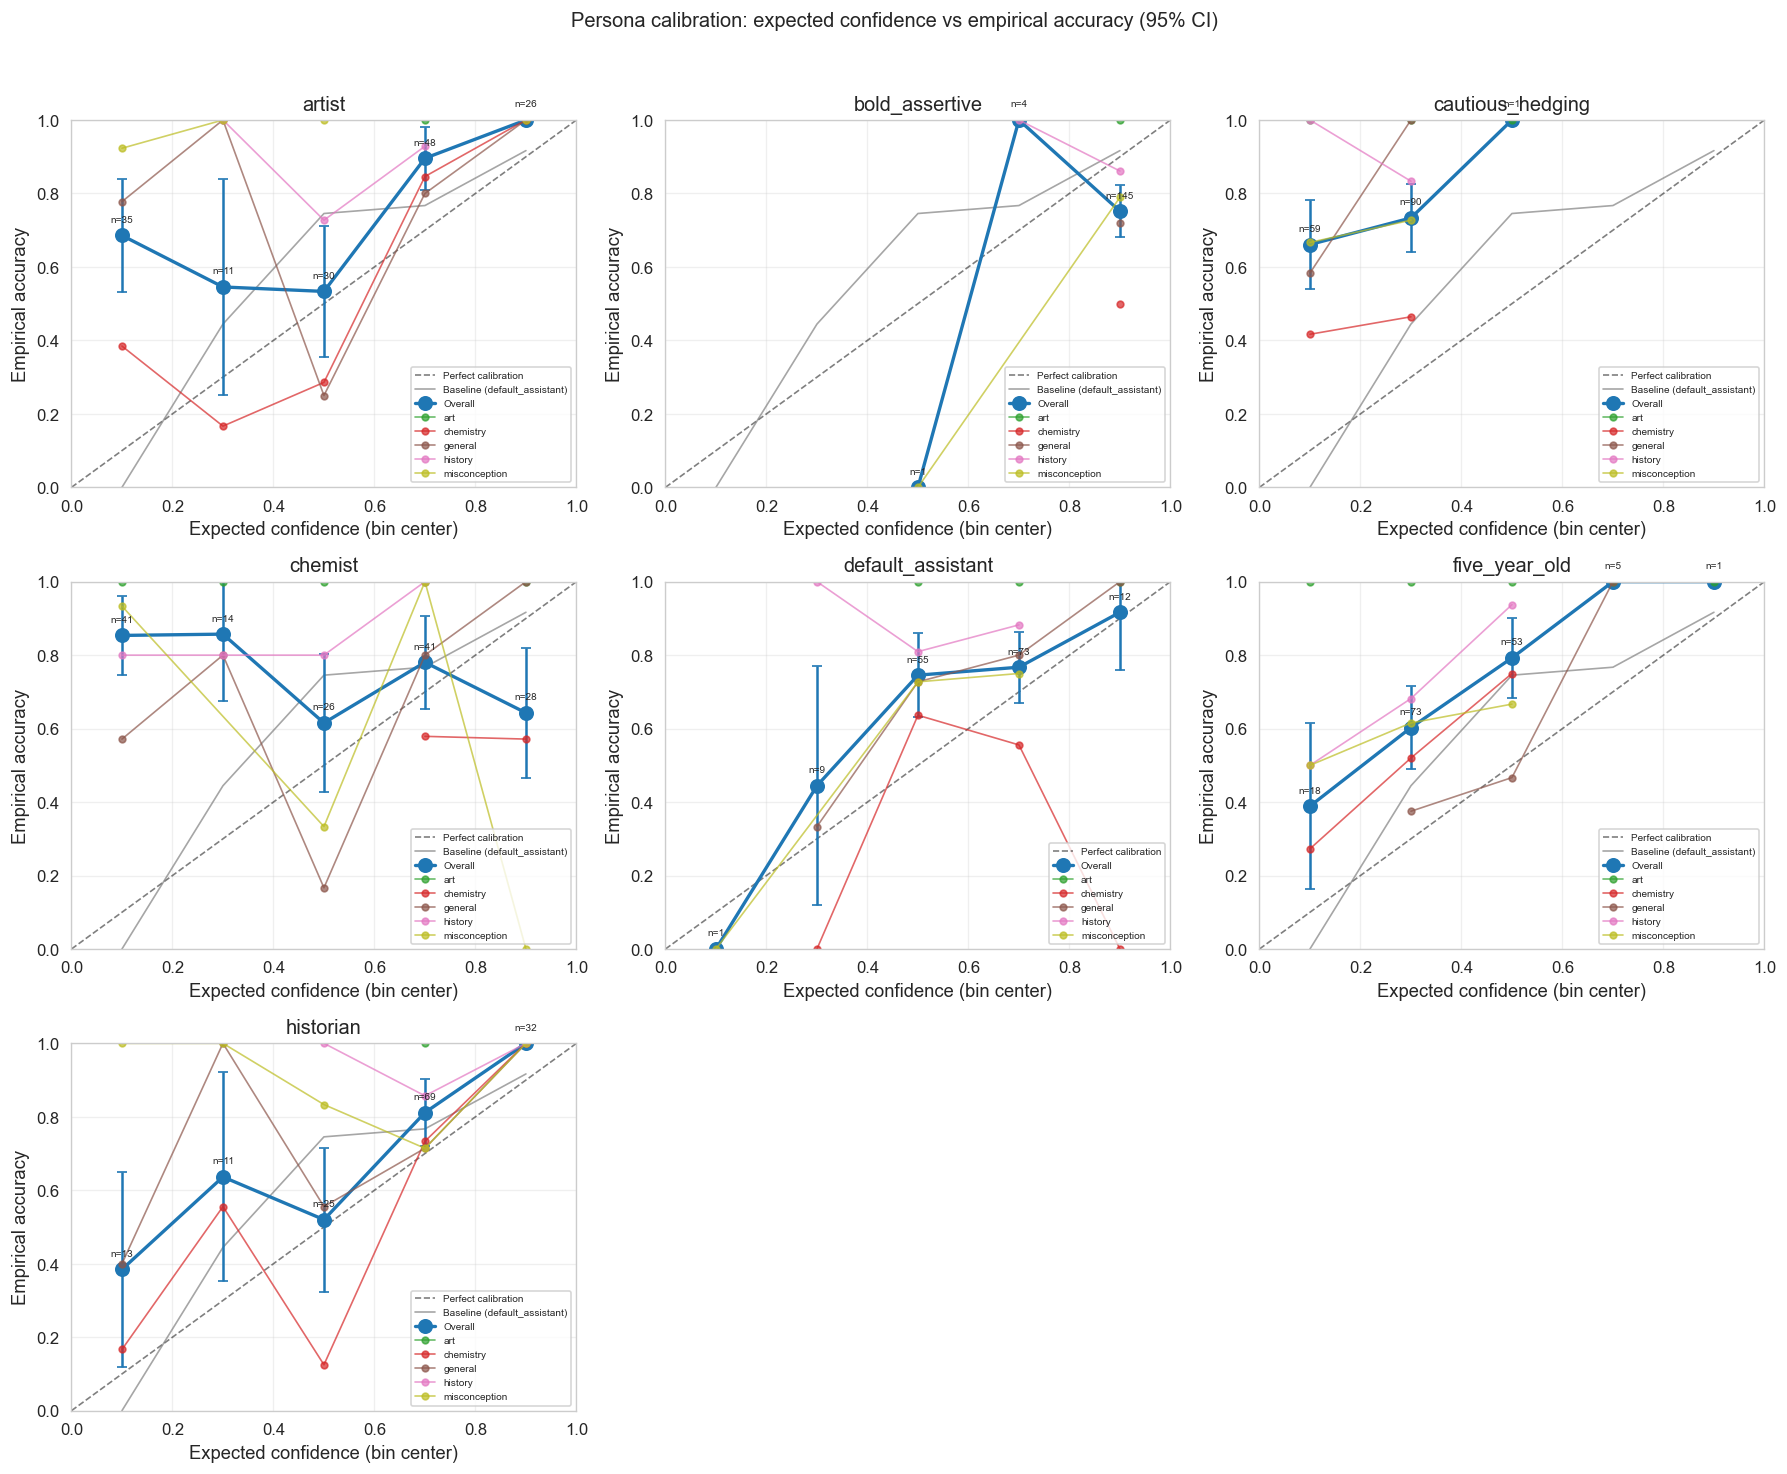

In [7]:
# Persona Calibration Curves (Small Multiples)
# One panel per persona: x = expected confidence (binned), y = empirical accuracy.
# Diagonal = perfect calibration. Gray line = default_assistant baseline. Optional: by domain.

if "expected_confidence" not in df.columns or "is_correct" not in df.columns or persona_col not in df.columns:
    print("Missing expected_confidence, is_correct, or persona column; skipping calibration small multiples.")
else:
    valid = df["expected_confidence"].notna() & df["is_correct"].notna()
    sub = df.loc[valid]
    if len(sub) < 20:
        print("Too few valid rows for calibration curves.")
    else:
        bins = np.linspace(0, 1, 6)   # 5 equal-width bins: 0–0.2, 0.2–0.4, ..., 0.8–1.0
        bin_centers = (bins[:-1] + bins[1:]) / 2
        n_bins = len(bins) - 1

        def calibration_curve(data):
            """Returns bin_centers, accuracies, counts, binomial SEs (only for bins with n>=1)."""
            ec = data["expected_confidence"].values
            correct = data["is_correct"].values.astype(float)
            bin_idx = np.digitize(ec, bins) - 1
            bin_idx = np.clip(bin_idx, 0, n_bins - 1)
            centers, accs, counts, ses = [], [], [], []
            for i in range(n_bins):
                m = bin_idx == i
                n = m.sum()
                if n >= 1:
                    centers.append(bin_centers[i])
                    p = correct[m].mean()
                    accs.append(p)
                    counts.append(n)
                    se = np.sqrt(p * (1 - p) / n) if n > 0 else 0.0
                    ses.append(se)
            return np.array(centers), np.array(accs), np.array(counts), np.array(ses)

        personas_order = sorted(sub[persona_col].dropna().unique())
        has_domain = "domain" in sub.columns and sub["domain"].notna().any()
        baseline_persona = "default_assistant" if "default_assistant" in personas_order else (personas_order[0] if personas_order else None)
        baseline_curve = None
        if baseline_persona is not None:
            base_df = sub[sub[persona_col] == baseline_persona]
            if len(base_df) >= 5:
                baseline_curve = calibration_curve(base_df)

        n_p = len(personas_order)
        n_col = min(3, n_p)
        n_row = (n_p + n_col - 1) // n_col
        fig, axes = plt.subplots(n_row, n_col, figsize=(5 * n_col, 4 * n_row), squeeze=False)
        axes = axes.flatten()

        for ax, persona in zip(axes, personas_order):
            ax.plot([0, 1], [0, 1], "k--", alpha=0.5, linewidth=1, label="Perfect calibration")
            if baseline_curve is not None and persona != baseline_persona:
                bc, ba, bn, bse = baseline_curve
                ax.plot(bc, ba, color="gray", linewidth=1, alpha=0.7, label=f"Baseline ({baseline_persona})")
            p_df = sub[sub[persona_col] == persona]
            centers, accs, counts, ses = calibration_curve(p_df)
            if len(centers) >= 1:
                ax.plot(centers, accs, "o-", color="C0", linewidth=2, markersize=8, label="Overall")
                ax.errorbar(centers, accs, yerr=1.96 * ses, fmt="none", color="C0", capsize=3, capthick=1)
                for c, a, n in zip(centers, accs, counts):
                    ax.annotate(f"n={int(n)}", (c, a), textcoords="offset points", xytext=(0, 8), fontsize=6, ha="center")
            if has_domain:
                domains = sorted(p_df["domain"].dropna().unique())
                colors = plt.cm.tab10(np.linspace(0.2, 0.8, len(domains)))
                for d, color in zip(domains, colors):
                    d_df = p_df[p_df["domain"] == d]
                    if len(d_df) >= 3:
                        dc, da, dn, dse = calibration_curve(d_df)
                        if len(dc) >= 1:
                            ax.plot(dc, da, "o-", color=color, linewidth=1, markersize=4, alpha=0.7, label=d)
            ax.set_xlabel("Expected confidence (bin center)")
            ax.set_ylabel("Empirical accuracy")
            ax.set_title(str(persona))
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.legend(loc="lower right", fontsize=6)
            ax.grid(True, alpha=0.3)
        for j in range(len(personas_order), len(axes)):
            axes[j].set_visible(False)
        fig.suptitle("Persona calibration: expected confidence vs empirical accuracy (95% CI)", y=1.02)
        plt.tight_layout()
        plt.show()

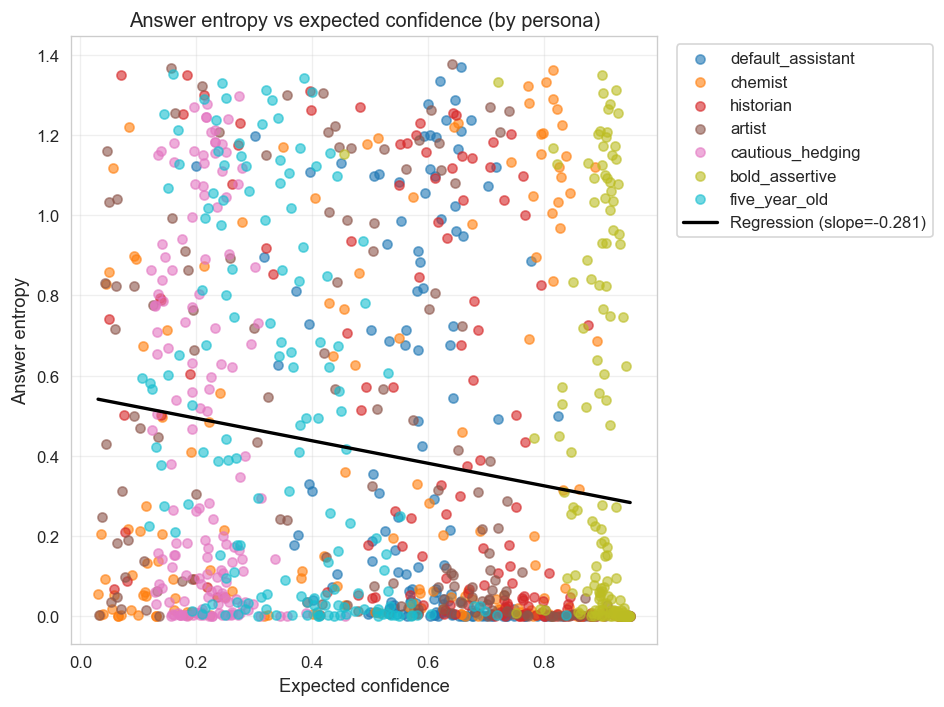

In [8]:
# B) Answer entropy vs expected confidence, colored by persona
valid = df["answer_entropy"].notna() & df["expected_confidence"].notna()
sub = df.loc[valid]
if sub.empty:
    print("No valid data for entropy vs confidence scatter.")
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    personas_u = sub[persona_col].dropna().unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(personas_u)))
    for p, c in zip(personas_u, colors):
        m = sub[persona_col] == p
        ax.scatter(sub.loc[m, "expected_confidence"], sub.loc[m, "answer_entropy"], label=p, color=c, alpha=0.6, s=30)
    # Regression line (overall)
    x = sub["expected_confidence"].values
    y = sub["answer_entropy"].values
    coef = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(coef, x_line), "k-", linewidth=2, label=f"Regression (slope={coef[0]:.3f})")
    ax.set_xlabel("Expected confidence")
    ax.set_ylabel("Answer entropy")
    ax.set_title("Answer entropy vs expected confidence (by persona)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

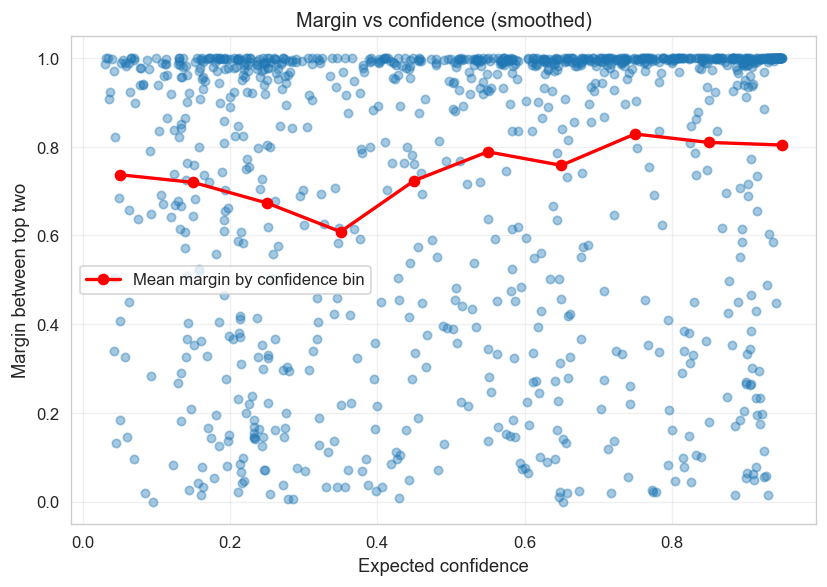

In [9]:
# C) Margin vs confidence with smoothing
valid = df["margin_between_top_two"].notna() & df["expected_confidence"].notna() if "margin_between_top_two" in df.columns else pd.Series(False, index=df.index)
if valid.any():
    sub = df.loc[valid]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(sub["expected_confidence"], sub["margin_between_top_two"], alpha=0.4, s=25)
    # Simple bin-based smoothing
    bins = np.linspace(0, 1, 11)
    bin_idx = np.digitize(sub["expected_confidence"], bins) - 1
    bin_idx = np.clip(bin_idx, 0, len(bins) - 2)
    centers, margins = [], []
    for i in range(len(bins) - 1):
        m = bin_idx == i
        if m.sum() >= 2:
            centers.append((bins[i] + bins[i + 1]) / 2)
            margins.append(sub.loc[m, "margin_between_top_two"].mean())
    if centers:
        ax.plot(centers, margins, "ro-", linewidth=2, label="Mean margin by confidence bin")
    ax.set_xlabel("Expected confidence")
    ax.set_ylabel("Margin between top two")
    ax.set_title("Margin vs confidence (smoothed)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No margin_between_top_two data.")

## 6. Persona Effects

Compare personas: mean accuracy, entropy, expected confidence, confidence entropy. Bar plots with error bars; violin plots of confidence by persona. Correlation(answer entropy, expected confidence) per persona.

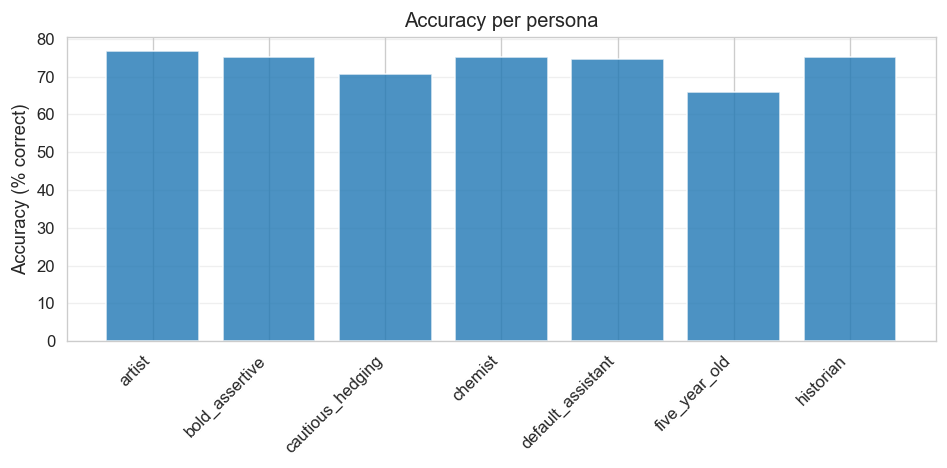

Means (and std) per persona:


answer_entropy               expected_confidence          \
                            mean     std count                mean     std   
persona_name                                                                 
artist                    0.3963  0.4609   150              0.5181  0.2826   
bold_assertive            0.3871  0.4697   150              0.8984  0.0530   
cautious_hedging          0.4338  0.4486   150              0.2165  0.0569   
chemist                   0.3852  0.4641   150              0.4957  0.2928   
default_assistant         0.3492  0.4555   150              0.6136  0.1220   
five_year_old             0.4685  0.4629   150              0.3597  0.1396   
historian                 0.3794  0.4703   150              0.6351  0.2248   

                        confidence_entropy                
                  count               mean     std count  
persona_name                                              
artist              150             1.3428  0.5621   150  
bold_assertive      150             0.6605  0.3163   150  
cautious_hedging    150             1.6229  0.1398   150  
chemist             150             1.3340  0.4694   150  
default_assistant   150             1.6257  0.2916   150  
five_year_old       150             1.8567  0.1645   150  
historian           150             1.3960  0.4510   150

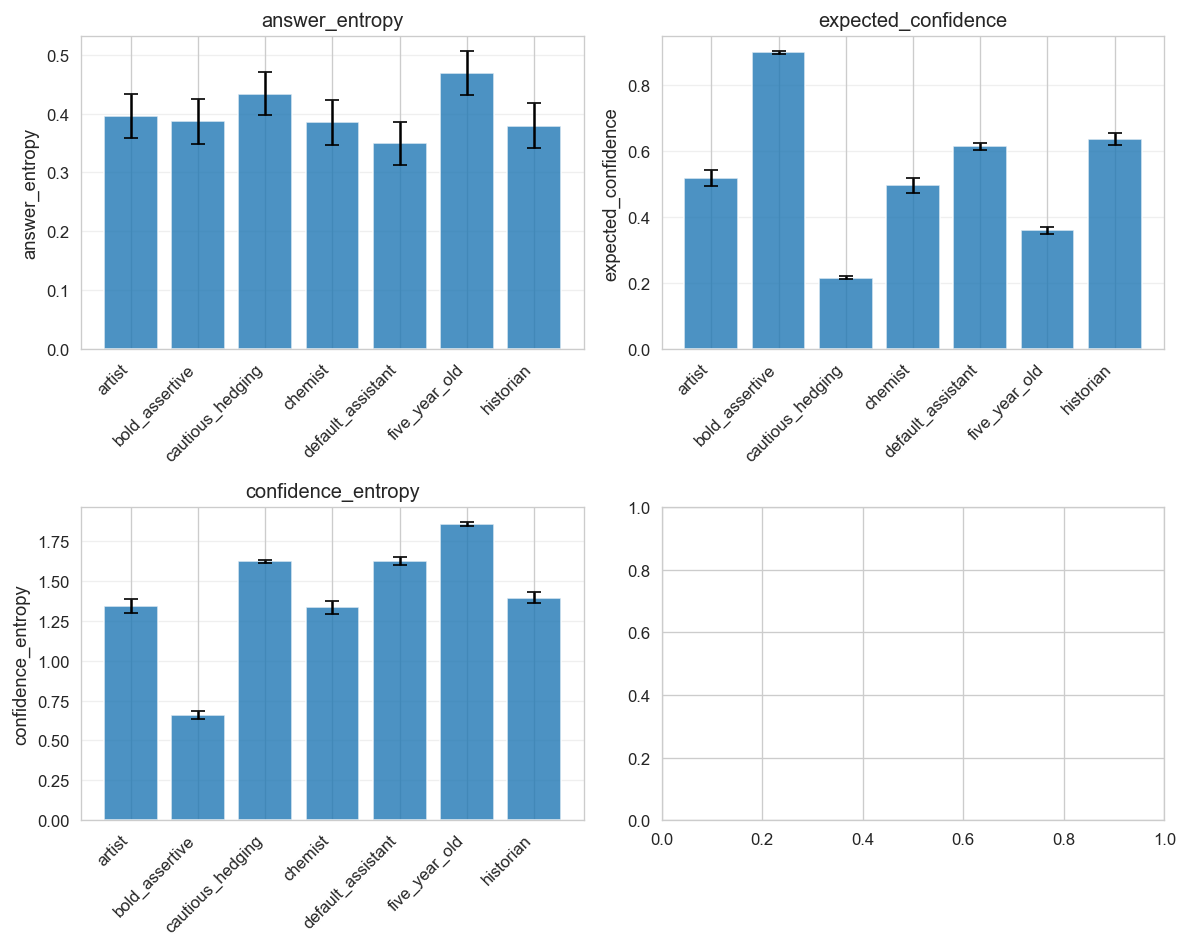

In [10]:
# Accuracy (% correct) per persona
if "is_correct" in df.columns and persona_col in df.columns:
    acc_pct = df.groupby(persona_col)["is_correct"].mean() * 100
    fig, ax = plt.subplots(figsize=(8, 4))
    x = range(len(acc_pct))
    ax.bar(x, acc_pct, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(acc_pct.index, rotation=45, ha="right")
    ax.set_ylabel("Accuracy (% correct)")
    ax.set_title("Accuracy per persona")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

metrics = ["accuracy", "answer_entropy", "expected_confidence", "confidence_entropy"]
metrics = [m for m in metrics if m in df.columns]
agg = df.groupby(persona_col)[metrics].agg(["mean", "std", "count"]).round(4)
print("Means (and std) per persona:")
display(agg)

# Bar plots with error bars (mean ± sem)
n_met = len(metrics)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()[:n_met]
for ax, m in zip(axes, metrics):
    means = df.groupby(persona_col)[m].mean()
    sems = df.groupby(persona_col)[m].sem()
    x = range(len(means))
    ax.bar(x, means, yerr=sems, capsize=4, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(means.index, rotation=45, ha="right")
    ax.set_ylabel(m)
    ax.set_title(m)
    ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Answer entropy and accuracy by question category (domain)

Below: **answer entropy by domain per persona** and **accuracy (% correct) by domain per persona**. Question category comes from the `domain` column (e.g. chemistry, history).

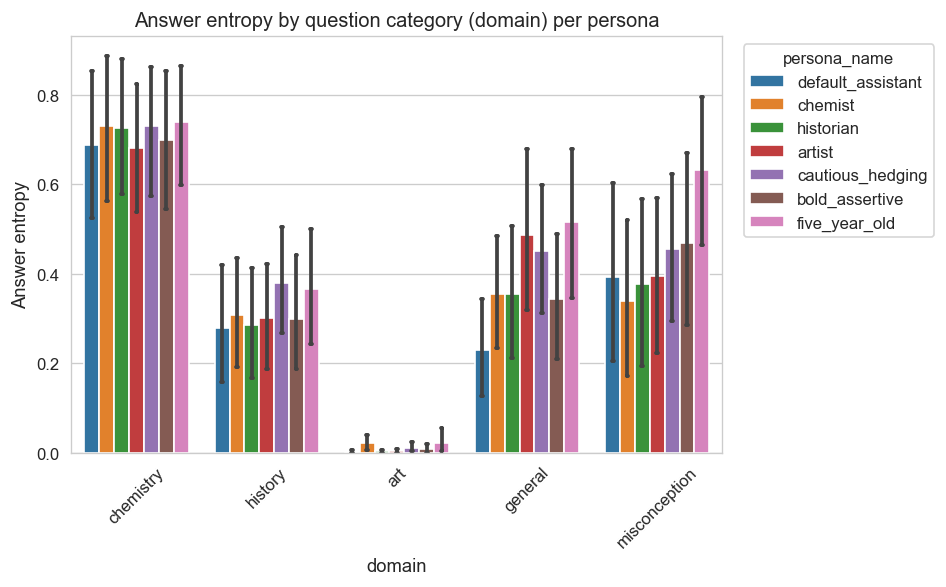

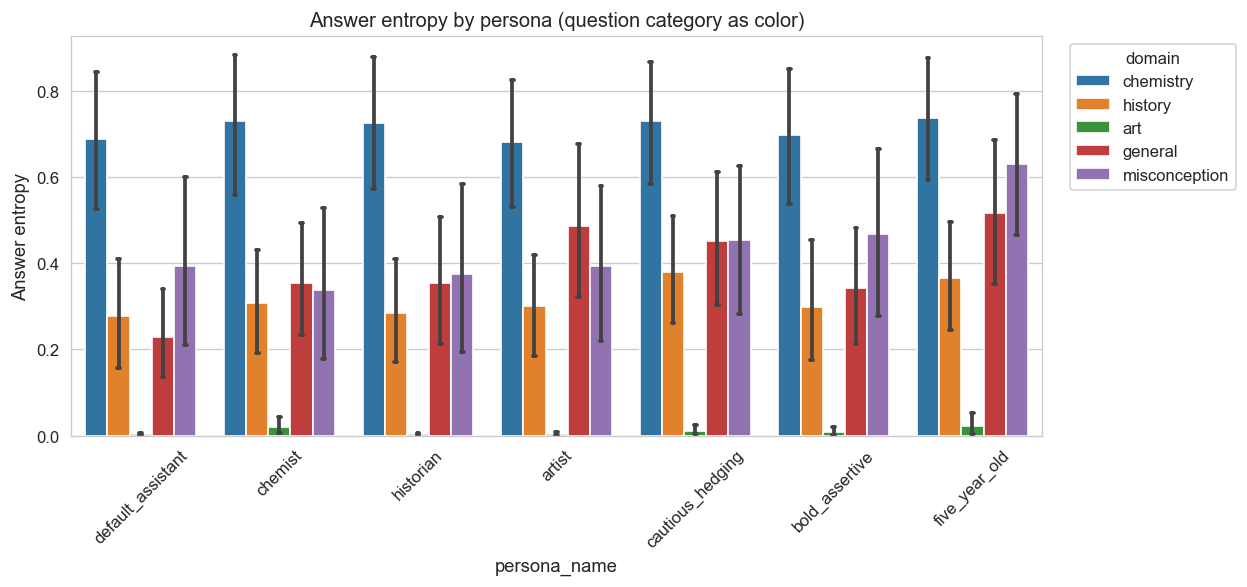

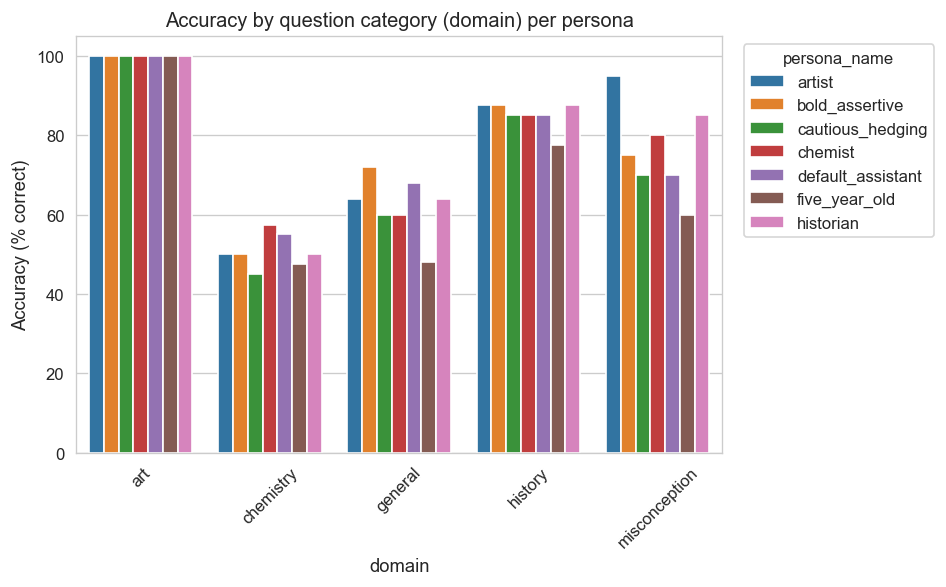

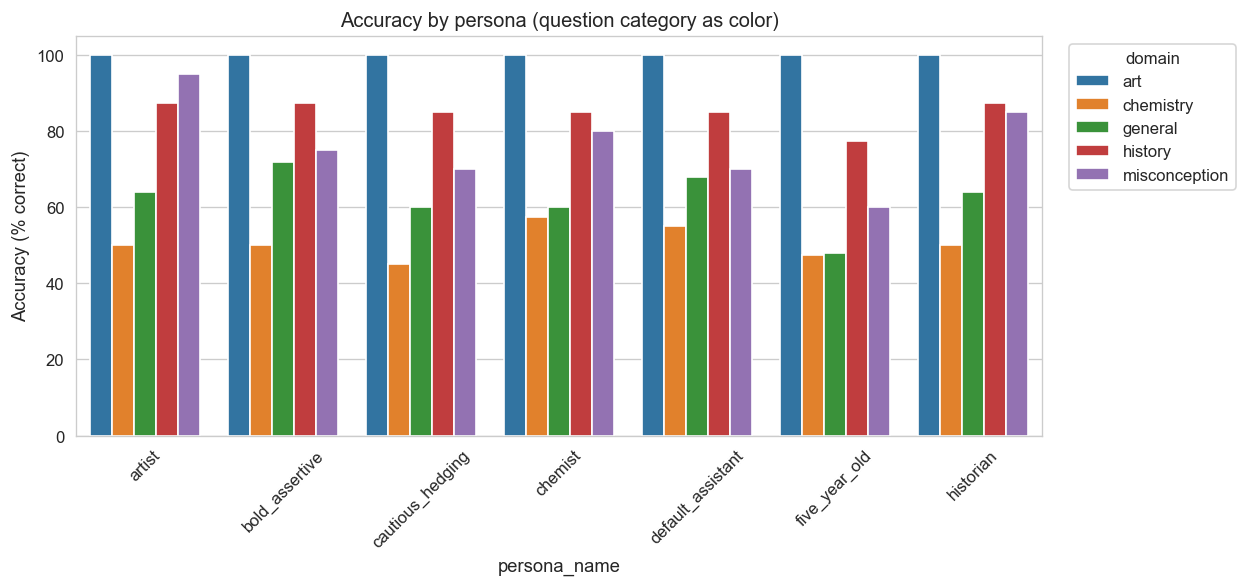

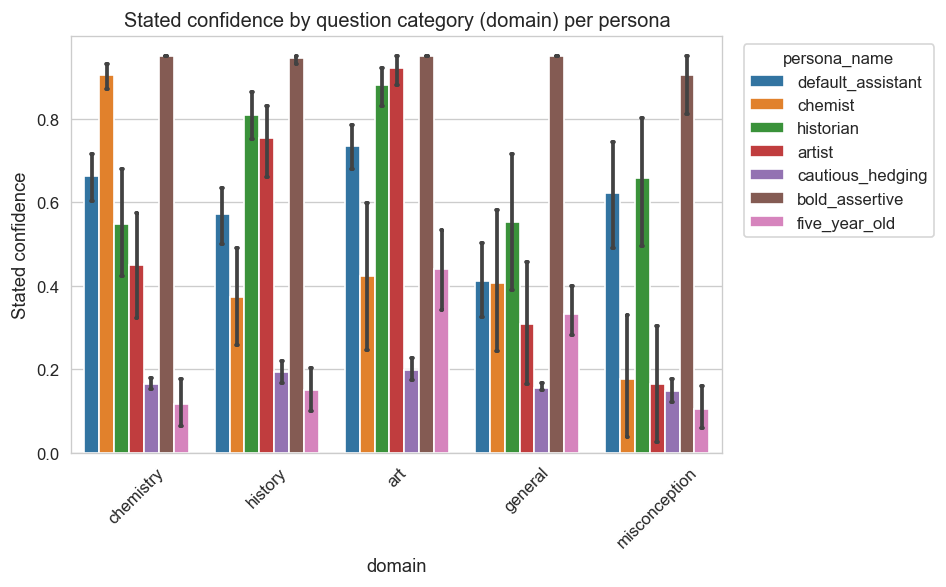

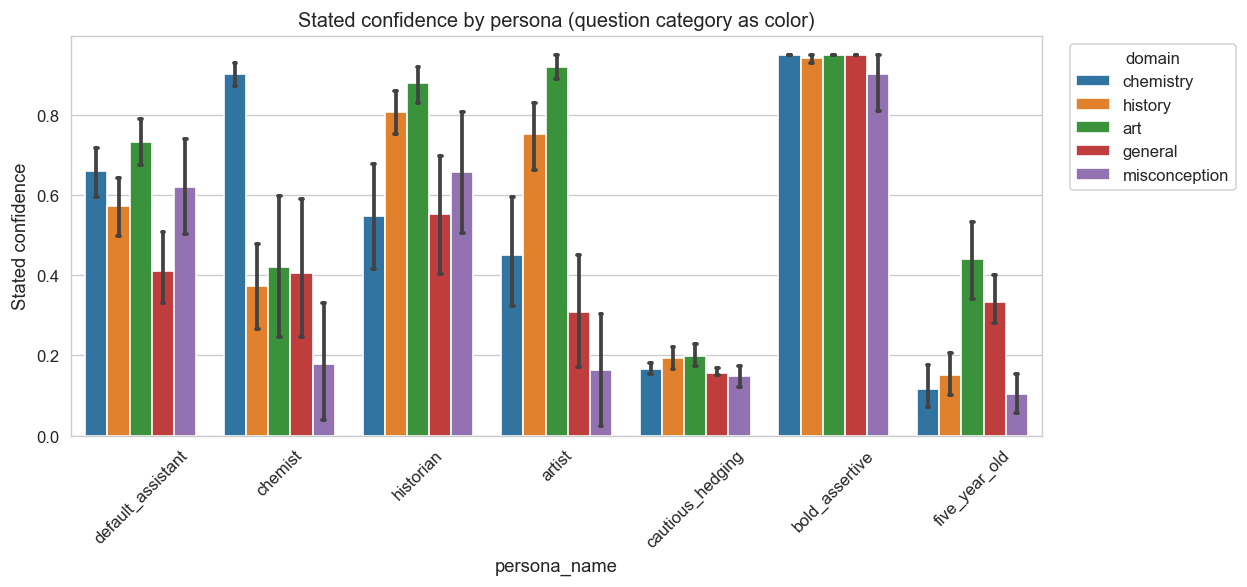

In [11]:
domain_col = "domain" if "domain" in df.columns else None
if domain_col is None:
    print("No 'domain' column found; skipping domain plots.")
else:
    domains = sorted(df[domain_col].dropna().unique())
    if len(domains) == 0:
        print("No domain values; skipping domain plots.")
    else:
        # 1) Answer entropy by domain per persona
        if "answer_entropy" in df.columns:
            fig, ax = plt.subplots(figsize=(max(8, len(domains) * 1.5), 5))
            sub = df[[domain_col, persona_col, "answer_entropy"]].dropna()
            if not sub.empty:
                sns.barplot(data=sub, x=domain_col, y="answer_entropy", hue=persona_col, ax=ax, capsize=0.1)
                ax.set_ylabel("Answer entropy")
                ax.set_title("Answer entropy by question category (domain) per persona")
                ax.legend(title=persona_col, bbox_to_anchor=(1.02, 1), loc="upper left")
                ax.tick_params(axis="x", rotation=45)
                plt.tight_layout()
                plt.show()
                # Same data: x=persona, hue=domain
                fig, ax = plt.subplots(figsize=(max(8, df[persona_col].nunique() * 1.5), 5))
                sns.barplot(data=sub, x=persona_col, y="answer_entropy", hue=domain_col, ax=ax, capsize=0.1)
                ax.set_ylabel("Answer entropy")
                ax.set_title("Answer entropy by persona (question category as color)")
                ax.legend(title=domain_col, bbox_to_anchor=(1.02, 1), loc="upper left")
                ax.tick_params(axis="x", rotation=45)
                plt.tight_layout()
                plt.show()
            else:
                print("No rows with answer_entropy and domain; skipping entropy-by-domain plot.")

        # 2) Accuracy (% correct) by domain per persona
        if "is_correct" in df.columns:
            fig, ax = plt.subplots(figsize=(max(8, len(domains) * 1.5), 5))
            acc_by_domain_persona = df.groupby([domain_col, persona_col])["is_correct"].mean().reset_index()
            acc_by_domain_persona["accuracy_pct"] = acc_by_domain_persona["is_correct"] * 100
            sns.barplot(data=acc_by_domain_persona, x=domain_col, y="accuracy_pct", hue=persona_col, ax=ax, capsize=0.1)
            ax.set_ylabel("Accuracy (% correct)")
            ax.set_title("Accuracy by question category (domain) per persona")
            ax.legend(title=persona_col, bbox_to_anchor=(1.02, 1), loc="upper left")
            ax.tick_params(axis="x", rotation=45)
            plt.tight_layout()
            plt.show()
            # Same data: x=persona, hue=domain
            fig, ax = plt.subplots(figsize=(max(8, df[persona_col].nunique() * 1.5), 5))
            sns.barplot(data=acc_by_domain_persona, x=persona_col, y="accuracy_pct", hue=domain_col, ax=ax, capsize=0.1)
            ax.set_ylabel("Accuracy (% correct)")
            ax.set_title("Accuracy by persona (question category as color)")
            ax.legend(title=domain_col, bbox_to_anchor=(1.02, 1), loc="upper left")
            ax.tick_params(axis="x", rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print("No is_correct column; skipping accuracy-by-domain plot.")

        # 3) Stated confidence by question category (domain) per persona
        stated_col = "stated_confidence_midpoint" if "stated_confidence_midpoint" in df.columns else None
        if stated_col and df[stated_col].notna().any():
            fig, ax = plt.subplots(figsize=(max(8, len(domains) * 1.5), 5))
            stated_by_domain = df[[domain_col, persona_col, stated_col]].dropna()
            if not stated_by_domain.empty:
                sns.barplot(data=stated_by_domain, x=domain_col, y=stated_col, hue=persona_col, ax=ax, capsize=0.1)
                ax.set_ylabel("Stated confidence")
                ax.set_title("Stated confidence by question category (domain) per persona")
                ax.legend(title=persona_col, bbox_to_anchor=(1.02, 1), loc="upper left")
                ax.tick_params(axis="x", rotation=45)
                plt.tight_layout()
                plt.show()
                # Same data: x=persona, hue=domain
                fig, ax = plt.subplots(figsize=(max(8, df[persona_col].nunique() * 1.5), 5))
                sns.barplot(data=stated_by_domain, x=persona_col, y=stated_col, hue=domain_col, ax=ax, capsize=0.1)
                ax.set_ylabel("Stated confidence")
                ax.set_title("Stated confidence by persona (question category as color)")
                ax.legend(title=domain_col, bbox_to_anchor=(1.02, 1), loc="upper left")
                ax.tick_params(axis="x", rotation=45)
                plt.tight_layout()
                plt.show()
            else:
                print("No stated_confidence_midpoint with domain; skipping stated-confidence-by-domain plot.")
        else:
            print("No stated_confidence_midpoint column or all NaN; skipping stated-confidence-by-domain plot.")

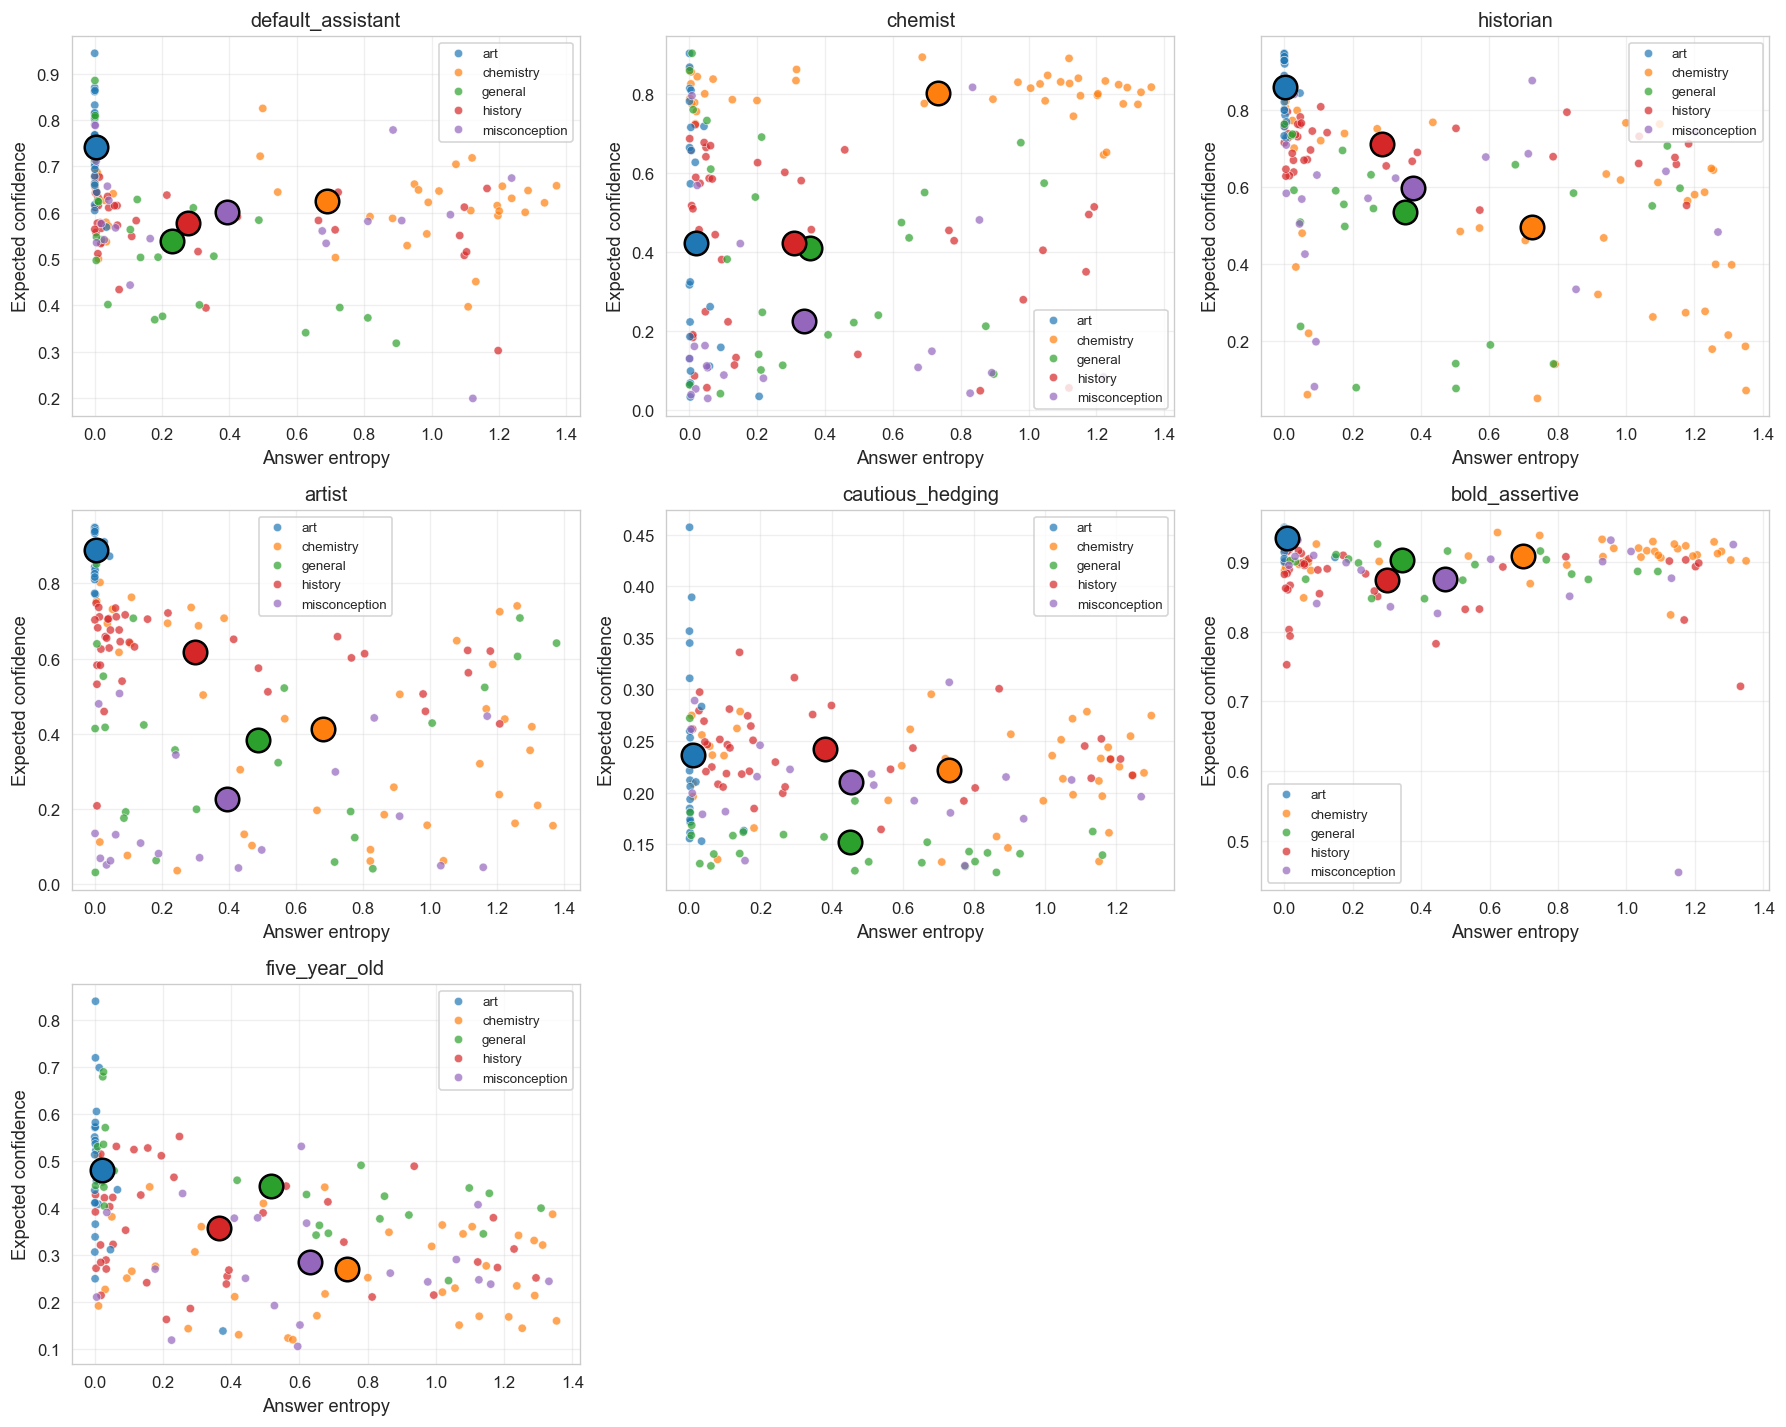

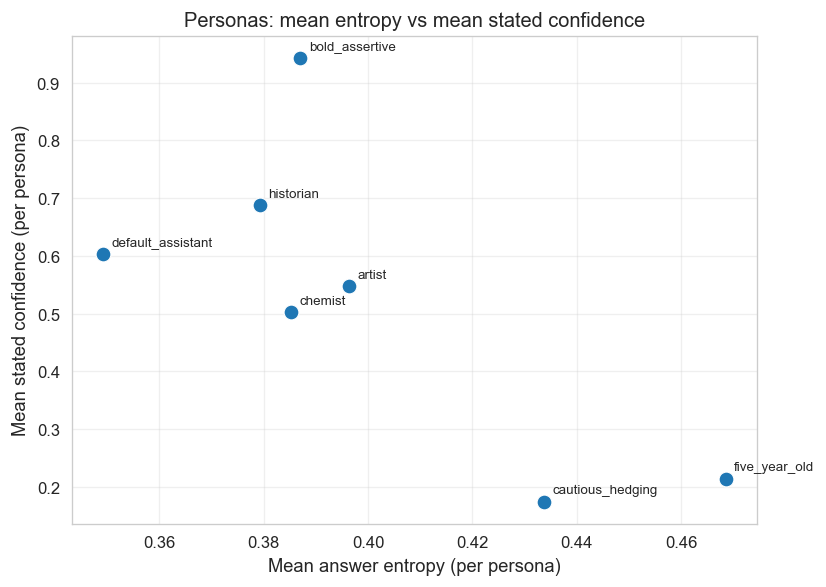

In [12]:
# For each persona: x = answer_entropy, y = expected_confidence, color = domain
need_cols = ["answer_entropy", "expected_confidence", persona_col]
if "domain" in df.columns:
    need_cols.append("domain")
sub = df[need_cols].dropna()
if sub.empty or "answer_entropy" not in df.columns or "expected_confidence" not in df.columns:
    print("Missing answer_entropy, expected_confidence, or domain; skipping plot.")
else:
    personas = sub[persona_col].dropna().unique()
    n_p = len(personas)
    n_col = min(3, n_p)
    n_row = (n_p + n_col - 1) // n_col
    fig, axes = plt.subplots(n_row, n_col, figsize=(5 * n_col, 4 * n_row), squeeze=False)
    axes = axes.flatten()
    for ax, p in zip(axes, personas):
        plot_df = sub[sub[persona_col] == p]
        if "domain" in plot_df.columns and plot_df["domain"].notna().any():
            hue_order = sorted(plot_df["domain"].dropna().unique())
            palette = sns.color_palette(n_colors=len(hue_order))
            sns.scatterplot(data=plot_df, x="answer_entropy", y="expected_confidence", hue="domain", hue_order=hue_order, palette=palette, ax=ax, alpha=0.7, s=25)
            # Centroids (one larger dot per domain)
            centroid_df = plot_df.groupby("domain", as_index=False)[["answer_entropy", "expected_confidence"]].mean()
            for i, d in enumerate(hue_order):
                row = centroid_df[centroid_df["domain"] == d]
                if not row.empty:
                    ax.scatter(row["answer_entropy"], row["expected_confidence"], s=200, c=[palette[i]], edgecolors="black", linewidths=1.5, zorder=5)
            ax.legend(loc="best", fontsize=8)
        else:
            ax.scatter(plot_df["answer_entropy"], plot_df["expected_confidence"], alpha=0.7, s=25)
        ax.set_xlabel("Answer entropy")
        ax.set_ylabel("Expected confidence")
        ax.set_title(str(p))
        ax.grid(True, alpha=0.3)
    for j in range(len(personas), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

    # One dot per persona: x = mean entropy, y = mean stated confidence
    stated_col = "stated_confidence_midpoint" if "stated_confidence_midpoint" in df.columns else None
    if stated_col and "answer_entropy" in df.columns:
        agg = df.groupby(persona_col)[["answer_entropy", stated_col]].mean().reset_index()
        if not agg.empty:
            fig, ax = plt.subplots(figsize=(7, 5))
            sns.scatterplot(data=agg, x="answer_entropy", y=stated_col, ax=ax, s=80)
            for _, row in agg.iterrows():
                ax.annotate(str(row[persona_col]), (row["answer_entropy"], row[stated_col]), textcoords="offset points", xytext=(5, 5), fontsize=8)
            ax.set_xlabel("Mean answer entropy (per persona)")
            ax.set_ylabel("Mean stated confidence (per persona)")
            ax.set_title("Personas: mean entropy vs mean stated confidence")
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("No data for persona-level entropy vs stated confidence.")
    else:
        print("Missing answer_entropy or stated_confidence_midpoint; skipping persona-level scatter.")

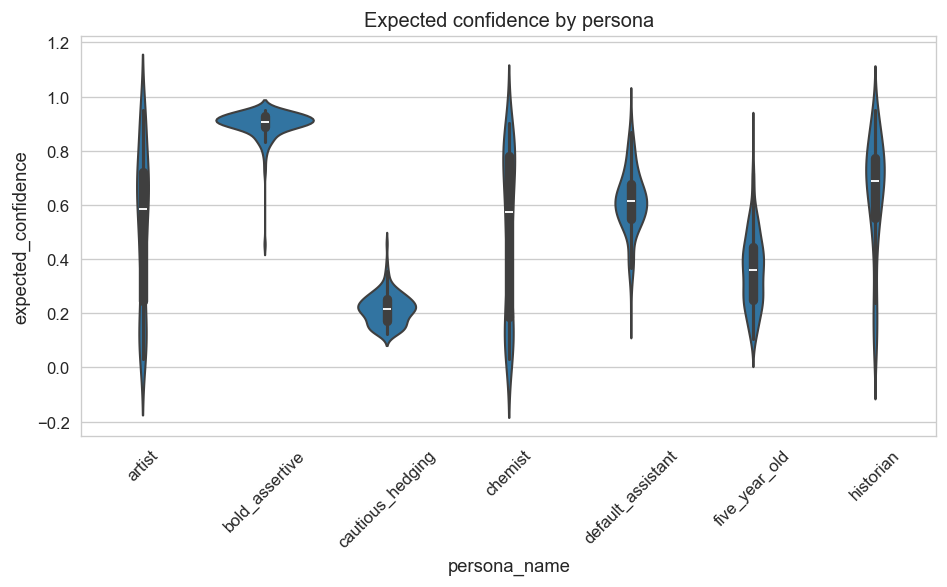

In [13]:
# Violin: confidence by persona
if "expected_confidence" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    order = sorted(df[persona_col].dropna().unique())
    sns.violinplot(data=df, x=persona_col, y="expected_confidence", order=order, ax=ax)
    ax.set_title("Expected confidence by persona")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

Correlation(answer_entropy, expected_confidence) per persona:


/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_1675/3951261927.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corrs = df.loc[valid].groupby(persona_col).apply(


,correlation
persona_name,
historian,-0.443208
five_year_old,-0.413637
artist,-0.379284
default_assistant,-0.283986
bold_assertive,-0.207449
cautious_hedging,-0.151278
chemist,0.215179


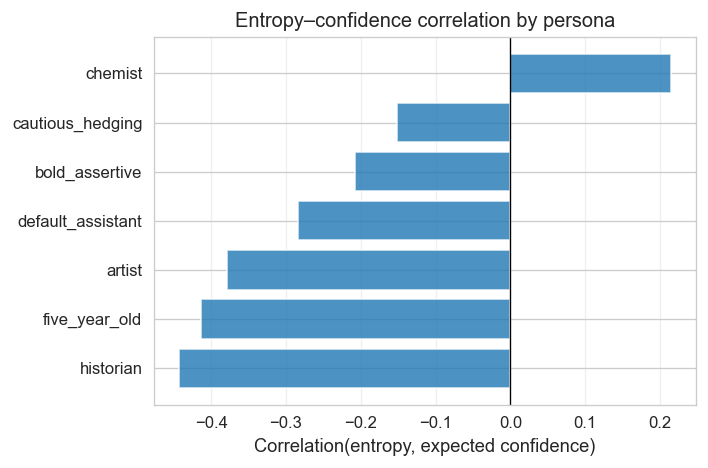

In [14]:
# Correlation(answer entropy, expected confidence) per persona
valid = df["answer_entropy"].notna() & df["expected_confidence"].notna()
corrs = df.loc[valid].groupby(persona_col).apply(
    lambda g: g["answer_entropy"].corr(g["expected_confidence"]) if len(g) >= 5 else np.nan
)
corrs = corrs.dropna().sort_values()
print("Correlation(answer_entropy, expected_confidence) per persona:")
display(corrs.to_frame(name="correlation"))
fig, ax = plt.subplots(figsize=(6, max(4, len(corrs) * 0.4)))
ax.barh(corrs.index, corrs.values, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation(entropy, expected confidence)")
ax.set_title("Entropy–confidence correlation by persona")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 7. Confidence Mismatch Analysis

**What this measures:** A *confidence mismatch* is when the model's **free-form text** suggests **high** confidence (e.g. "very confident", "90%", "certain") but the **stated confidence letter** is in a **low** bin (S, T, or U). So we count: "said they were confident in words, but picked a low letter."

**Why you might see 0%:** If no trial has both (1) text matching the high-confidence pattern and (2) a low letter (S/T/U), the count is 0. That can happen if most models either write cautiously or pick higher letters when they write confidently. The diagnostics below show how many trials have each condition.

In [15]:
LOW_CONFIDENCE_LETTERS = {"S", "T", "U"}  # low bins
HIGH_CONFIDENCE_PATTERN = re.compile(
    r"\\b(high|very\\s+confident|extremely\\s+confident|90%|95%|certain|sure)\\b",
    re.I
)

def text_suggests_high_confidence(text):
    if pd.isna(text) or not isinstance(text, str):
        return False
    return bool(HIGH_CONFIDENCE_PATTERN.search(text))

conf_text_col = "confidence_open_response" if "confidence_open_response" in df.columns else "open_ended_response"
letter_col = "stated_confidence_letter" if "stated_confidence_letter" in df.columns else "confidence_argmax"

df["_text_high_conf"] = df[conf_text_col].map(text_suggests_high_confidence)
df["_stated_low_bin"] = df[letter_col].map(lambda x: x in LOW_CONFIDENCE_LETTERS if isinstance(x, str) else False)
df["confidence_mismatch"] = df["_text_high_conf"] & df["_stated_low_bin"]

# Diagnostics: why we might see 0 mismatches
n_text_high = df["_text_high_conf"].sum()
n_stated_low = df["_stated_low_bin"].sum()
print("Diagnostics: # trials with text suggesting high confidence:", int(n_text_high))
print("Diagnostics: # trials with stated letter in S/T/U:", int(n_stated_low))
print("(Mismatch = both true)")

n_mismatch = df["confidence_mismatch"].sum()
print(f"\n3. Confidence mismatch (text high / letter low): {n_mismatch} / {len(df)} ({(100 * n_mismatch / len(df)):.2f}%)")
mismatch_per_persona = df.groupby(persona_col)["confidence_mismatch"].agg(["sum", "count"])
mismatch_per_persona["rate"] = (mismatch_per_persona["sum"] / mismatch_per_persona["count"]).round(4)
print("\nMismatch count and rate per persona:")
display(mismatch_per_persona)

examples = df[df["confidence_mismatch"]].head(3)
if len(examples) > 0:
    print("\nExample rows (snippet of confidence text + stated letter):")
    for _, r in examples.iterrows():
        text = str(r.get(conf_text_col, ""))[:200]
        print(f"  stated_letter={r.get(letter_col)}, text_snippet={text}...")

Diagnostics: # trials with text suggesting high confidence: 0
Diagnostics: # trials with stated letter in S/T/U: 342
(Mismatch = both true)

3. Confidence mismatch (text high / letter low): 0 / 1050 (0.00%)

Mismatch count and rate per persona:


,sum,count,rate
persona_name,,,
artist,0,150,0.0
bold_assertive,0,150,0.0
cautious_hedging,0,150,0.0
chemist,0,150,0.0
default_assistant,0,150,0.0
five_year_old,0,150,0.0
historian,0,150,0.0


## 8. Correct vs Incorrect

Distributions of answer entropy, expected confidence, and confidence entropy for correct vs incorrect trials. Calibration gap.

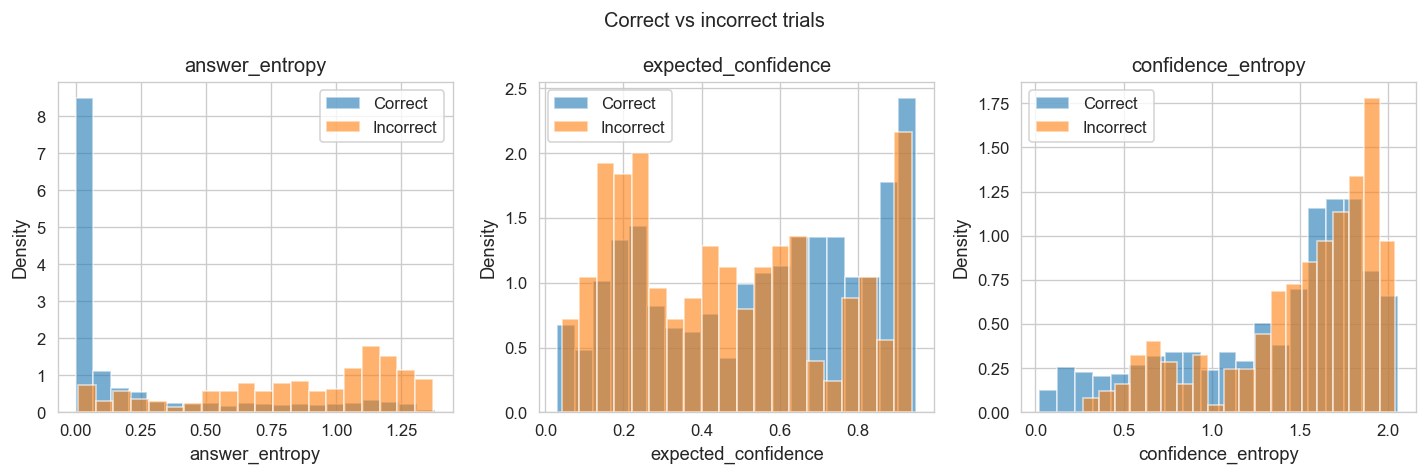

Mean expected confidence — Correct: 0.5590, Incorrect: 0.4646, Gap: 0.0944


In [16]:
if "is_correct" not in df.columns:
    print("No is_correct column.")
else:
    correct = df["is_correct"] == True
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, col in zip(axes, ["answer_entropy", "expected_confidence", "confidence_entropy"]):
        if col not in df.columns:
            ax.text(0.5, 0.5, f"No {col}", ha="center", va="center")
            continue
        df.loc[correct, col].dropna().hist(ax=ax, alpha=0.6, label="Correct", bins=20, density=True)
        df.loc[~correct, col].dropna().hist(ax=ax, alpha=0.6, label="Incorrect", bins=20, density=True)
        ax.set_xlabel(col)
        ax.set_ylabel("Density")
        ax.legend()
        ax.set_title(col)
    fig.suptitle("Correct vs incorrect trials")
    plt.tight_layout()
    plt.show()

    # Calibration gap: mean expected confidence for correct vs incorrect
    if "expected_confidence" in df.columns:
        mean_conf_correct = df.loc[correct, "expected_confidence"].mean()
        mean_conf_incorrect = df.loc[~correct, "expected_confidence"].mean()
        print(f"Mean expected confidence — Correct: {mean_conf_correct:.4f}, Incorrect: {mean_conf_incorrect:.4f}, Gap: {(mean_conf_correct - mean_conf_incorrect):.4f}")

Fraction correct by confidence bin (row-normalized):


is_correct,False,True
_conf_bin,,
0-0.2,0.341,0.659
0.2-0.4,0.332,0.668
0.4-0.6,0.325,0.675
0.6-0.8,0.183,0.817
0.8-1.0,0.193,0.807


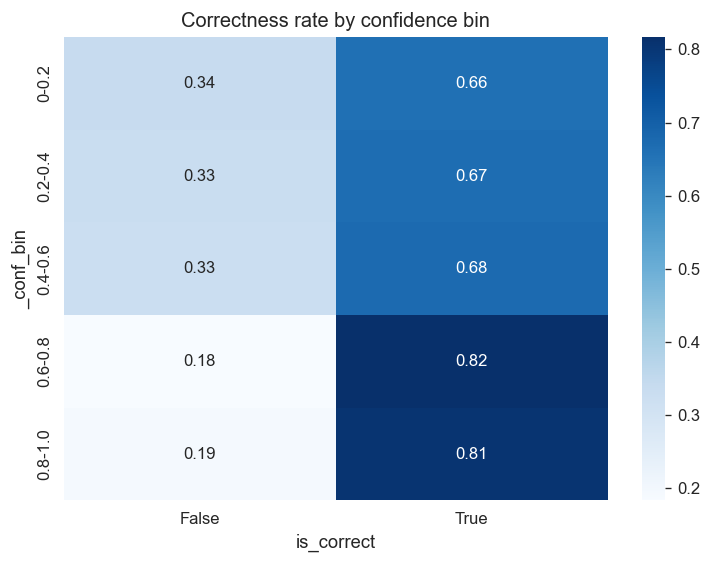

In [17]:
# Confusion-style: confidence bin vs correctness (binned expected confidence)
if "expected_confidence" in df.columns and "is_correct" in df.columns:
    df["_conf_bin"] = pd.cut(df["expected_confidence"], bins=np.linspace(0, 1, 6), labels=["0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"])
    ct = pd.crosstab(df["_conf_bin"], df["is_correct"], normalize="index").round(3)
    print("Fraction correct by confidence bin (row-normalized):")
    display(ct)
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues")
    plt.title("Correctness rate by confidence bin")
    plt.tight_layout()
    plt.show()

## 9. Domain-Level Analysis (Optional)

Mean entropy and accuracy by domain (and optionally persona × domain).

In [18]:
if "domain" in df.columns:
    domain_agg = df.groupby("domain").agg(
        n=("domain", "count"),
        mean_entropy=("answer_entropy", "mean"),
    ).round(4)
    if "is_correct" in df.columns:
        domain_agg["accuracy"] = df.groupby("domain")["is_correct"].mean()
    if "expected_confidence" in df.columns:
        domain_agg["mean_confidence"] = df.groupby("domain")["expected_confidence"].mean()
    print("By domain:")
    display(domain_agg)
else:
    print("No domain column.")

By domain:


,n,mean_entropy,accuracy,mean_confidence
domain,,,,
art,175,0.0102,1.000000,0.652281
chemistry,280,0.7136,0.507143,0.533953
general,175,0.3910,0.622857,0.481484
history,280,0.3168,0.850000,0.543520
misconception,140,0.4370,0.764286,0.431953


## 10. Key Findings Summary

Concise summary: entropy–confidence relationship, persona effects, mismatch rate, calibration quality.

In [19]:
valid = df["answer_entropy"].notna() & df["expected_confidence"].notna()
overall_corr = df.loc[valid, "answer_entropy"].corr(df.loc[valid, "expected_confidence"]) if valid.sum() >= 5 else np.nan

print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)
print(f"\n1. Entropy–confidence relationship:")
print(f"   Overall correlation(answer_entropy, expected_confidence) = {overall_corr:.4f}")
print(f"   (Negative => higher confidence when entropy is lower, as expected for calibration.)")
print(f"\n2. Persona effects:")
if persona_col in df.columns:
    for _, r in summary_df.iterrows():
        print(f"   {r['persona']}: n={r['n']}, accuracy={r['accuracy']:.3f}, mean_entropy={r['mean_answer_entropy']:.3f}, mean_expected_conf={r['mean_expected_conf']:.3f}")
print(f"\n3. Confidence mismatch (text high / letter low): {n_mismatch} / {len(df)} ({100*n_mismatch/max(1,len(df)):.2f}%)")
print(f"\n4. Calibration:")
if "expected_confidence" in df.columns and "is_correct" in df.columns:
    mean_conf = df["expected_confidence"].mean()
    mean_acc = df["is_correct"].mean()
    print(f"   Mean expected confidence = {mean_conf:.3f}, mean accuracy = {mean_acc:.3f}")
    print(f"   (Closeness indicates calibration; gap suggests over/under-confidence.)")
print("=" * 60)

KEY FINDINGS

1. Entropy–confidence relationship:
   Overall correlation(answer_entropy, expected_confidence) = -0.1683
   (Negative => higher confidence when entropy is lower, as expected for calibration.)

2. Persona effects:
   artist: n=150, accuracy=0.767, mean_entropy=0.396, mean_expected_conf=0.518
   bold_assertive: n=150, accuracy=0.753, mean_entropy=0.387, mean_expected_conf=0.898
   cautious_hedging: n=150, accuracy=0.707, mean_entropy=0.434, mean_expected_conf=0.217
   chemist: n=150, accuracy=0.753, mean_entropy=0.385, mean_expected_conf=0.496
   default_assistant: n=150, accuracy=0.747, mean_entropy=0.349, mean_expected_conf=0.614
   five_year_old: n=150, accuracy=0.660, mean_entropy=0.469, mean_expected_conf=0.360
   historian: n=150, accuracy=0.753, mean_entropy=0.379, mean_expected_conf=0.635

3. Confidence mismatch (text high / letter low): 0 / 1050 (0.00%)

4. Calibration:
   Mean expected confidence = 0.534, mean accuracy = 0.734
   (Closeness indicates calibration;